## Conceptos Clave de Reinforcement Learning (Aprendizaje por Refuerzo)

El Aprendizaje por Refuerzo (RL) es un área del aprendizaje automático donde un **agente** aprende a tomar **acciones** en un **entorno** para maximizar una **recompensa** acumulada. A diferencia del aprendizaje supervisado, el agente no recibe pares de entrada-salida correctos, sino que aprende a través de ensayo y error, recibiendo retroalimentación en forma de recompensas.

### Componentes Principales:

*   **Agente**: El sistema de aprendizaje que toma decisiones.
*   **Entorno**: El mundo en el que opera el agente.
*   **Estado (State)**: Una descripción completa o parcial de la situación actual del entorno.
*   **Acción (Action)**: Una decisión tomada por el agente en un estado dado.
*   **Política (Policy, π)**: La estrategia del agente, que mapea estados a acciones (o distribuciones de probabilidad sobre acciones). Es lo que el agente aprende.
*   **Recompensa (Reward, R)**: Una señal escalar que el entorno le da al agente después de una acción, indicando cuán buena o mala fue esa acción. El objetivo del agente es maximizar la suma acumulada de recompensas.
*   **Valor (Value Function, V o Q)**: Una predicción de la recompensa futura esperada a partir de un estado o par estado-acción. Ayuda al agente a evaluar la bondad de los estados o acciones a largo plazo.
*   **Función de Retorno (Return, G)**: La suma total de recompensas descontadas a partir de un momento dado.

El objetivo final del agente es encontrar una política óptima que maximice el retorno esperado.

## Gradiente de la Política (Policy Gradient)

El **Gradiente de la Política** es una clase de algoritmos en Reinforcement Learning que buscan optimizar directamente la política del agente. En lugar de aprender una función de valor para luego derivar una política, los métodos de gradiente de política ajustan los parámetros de la política para que las acciones que conducen a recompensas altas se vuelvan más probables.

La idea central es que si una acción particular en un estado dado lleva a un alto retorno, queremos aumentar la probabilidad de tomar esa acción en el futuro. Por el contrario, si una acción lleva a un bajo retorno, queremos disminuir su probabilidad.

### Ecuación General del Gradiente de la Política (REINFORCE):

El gradiente de la política a menudo se expresa de la siguiente manera:

$\nabla_\theta J(\theta) \approx \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) G_t \right]$

Donde:

*   $J(\theta)$: La función objetivo (normalmente el retorno esperado) que queremos maximizar, parametrizada por $\theta$.
*   $\theta$: Los parámetros de la política (por ejemplo, los pesos de una red neuronal).
*   $\mathbb{E}_{\tau \sim \pi_\theta}[\dots]$: La esperanza sobre las trayectorias (secuencias de estados, acciones, recompensas) generadas por la política $\pi_\theta$.
*   $\pi_\theta(a_t|s_t)$: La probabilidad de tomar la acción $a_t$ en el estado $s_t$ según la política actual.
*   $\nabla_\theta \log \pi_\theta(a_t|s_t)$: El gradiente del logaritmo de la probabilidad de la acción tomada. Este término indica cómo cambiar los parámetros $\theta$ para hacer que la acción $a_t$ sea más o menos probable.
*   $G_t$: El retorno (suma de recompensas futuras descontadas) a partir del tiempo $t$. Este término pondera el gradiente: si $G_t$ es alto, el gradiente empuja para aumentar la probabilidad de $a_t$; si es bajo, la disminuye.

En resumen, el gradiente de la política nos dice en qué dirección debemos ajustar los parámetros de nuestra política para obtener más recompensa en el futuro. Iterativamente, el agente ajusta sus parámetros en la dirección del gradiente para mejorar su rendimiento.

True rewards for each arm: [0.6220439  1.85008538]
Episode 0: Action Probs = [0.49 0.51], Avg Reward (last 100) = 0.88
Episode 100: Action Probs = [0.37 0.63], Avg Reward (last 100) = 1.24
Episode 200: Action Probs = [0.42 0.58], Avg Reward (last 100) = 1.32
Episode 300: Action Probs = [0.38 0.62], Avg Reward (last 100) = 1.41
Episode 400: Action Probs = [0.4 0.6], Avg Reward (last 100) = 1.14
Episode 500: Action Probs = [0.36 0.64], Avg Reward (last 100) = 1.4
Episode 600: Action Probs = [0.41 0.59], Avg Reward (last 100) = 1.58
Episode 700: Action Probs = [0.38 0.62], Avg Reward (last 100) = 1.38
Episode 800: Action Probs = [0.36 0.64], Avg Reward (last 100) = 1.22
Episode 900: Action Probs = [0.38 0.62], Avg Reward (last 100) = 1.46

Final policy parameters (theta): [-38.52 -38.22]
Final action probabilities: [0.43 0.57]


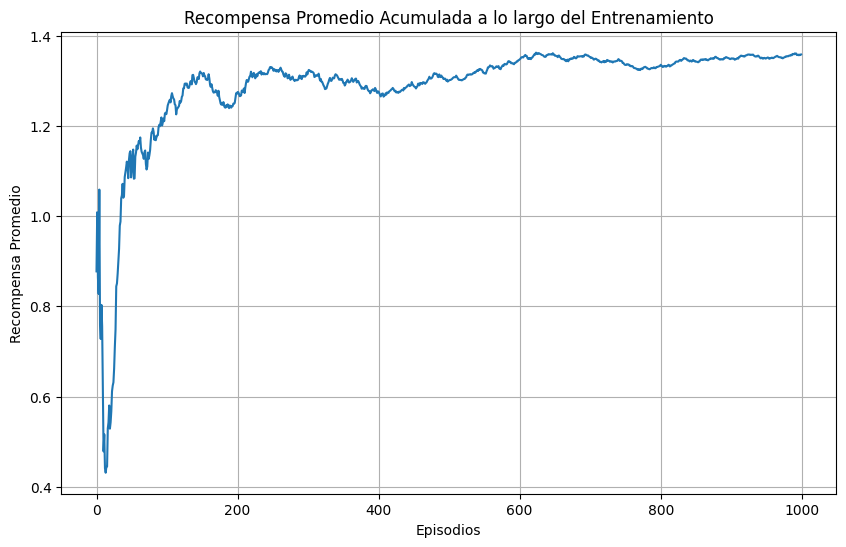

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Entorno Simple: 'Bandido Multi-Brazo' (Multi-Armed Bandit) ---
# Un entorno donde solo hay un estado y múltiples acciones (brazos).
# Cada brazo tiene una distribución de recompensa.

class MultiArmedBandit:
    def __init__(self, num_arms):
        self.num_arms = num_arms
        # Recompensas verdaderas (desconocidas para el agente)
        self.true_rewards = np.random.randn(num_arms)

    def pull_arm(self, action):
        # La recompensa es la recompensa verdadera más un ruido aleatorio
        return self.true_rewards[action] + np.random.randn()

# --- 2. Política Parametrizada ---
# Usaremos una política softmax para elegir acciones.
# Los 'logits' son los parámetros theta.

class Policy:
    def __init__(self, num_arms):
        self.num_arms = num_arms
        # Inicializamos los parámetros de la política (logits) a cero
        self.theta = np.zeros(num_arms)

    def get_action_probabilities(self):
        # Aplica softmax a los logits para obtener probabilidades
        exp_theta = np.exp(self.theta)
        return exp_theta / np.sum(exp_theta)

    def choose_action(self):
        probs = self.get_action_probabilities()
        return np.random.choice(self.num_arms, p=probs)

    def update_policy(self, gradients):
        # Actualiza los parámetros theta usando el gradiente
        self.theta += gradients

# --- 3. Cálculo del Gradiente de la Política (Simplificado) ---
# Para el bandido multi-brazo, el gradiente logarítmico es más simple.
# La fórmula para el gradiente de la política (para una sola acción y recompensa)
# es aproximadamente: grad_theta(log_pi(a|s)) * G_t
# En un MAB, no hay 's', y G_t es la recompensa inmediata R.

def calculate_policy_gradient(policy, action, reward):
    probs = policy.get_action_probabilities()
    # Gradiente del logaritmo de la probabilidad de la acción tomada
    log_prob_gradient = np.zeros(policy.num_arms)
    log_prob_gradient[action] = 1 - probs[action]
    log_prob_gradient -= probs # para otras acciones

    # Multiplicar por la recompensa (o el retorno G_t)
    gradient = log_prob_gradient * reward
    return gradient

# --- 4. Loop de Entrenamiento ---

num_arms = 2
bandit = MultiArmedBandit(num_arms)
policy = Policy(num_arms)

num_episodes = 1000 # Número de veces que el agente interactúa con el entorno
learning_rate = 0.1 # Tasa de aprendizaje para actualizar los parámetros de la política

rewards_history = []

print("True rewards for each arm:", bandit.true_rewards)

for episode in range(num_episodes):
    action = policy.choose_action()
    reward = bandit.pull_arm(action)

    # Calcular el gradiente de la política
    gradients = calculate_policy_gradient(policy, action, reward)

    # Aplicar el gradiente para actualizar los parámetros de la política
    # Aquí estamos usando un simple ascenso de gradiente
    policy.theta += learning_rate * gradients

    rewards_history.append(reward)

    if episode % 100 == 0:
        print(f"Episode {episode}: Action Probs = {policy.get_action_probabilities().round(2)}, Avg Reward (last 100) = {np.mean(rewards_history[-100:]).round(2)}")

print("\nFinal policy parameters (theta):", policy.theta.round(2))
print("Final action probabilities:", policy.get_action_probabilities().round(2))

# --- 5. Visualización de Resultados ---
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(rewards_history) / (np.arange(len(rewards_history)) + 1))
plt.title('Recompensa Promedio Acumulada a lo largo del Entrenamiento')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Promedio')
plt.grid(True)
plt.show()

### Explicación del Código:

Este código implementa una versión simplificada del algoritmo **REINFORCE** para un problema de **Bandido Multi-Brazo** (Multi-Armed Bandit - MAB). Un MAB es el caso más sencillo de RL, donde el agente está en un único estado y elige entre varias acciones (brazos), recibiendo una recompensa inmediata.

1.  **`MultiArmedBandit` Clase del Entorno**:
    *   Define un entorno con un número fijo de 'brazos'.
    *   Cada brazo tiene una `true_reward` subyacente (que el agente no conoce directamente).
    *   El método `pull_arm(action)` devuelve una recompensa que es la `true_reward` del brazo elegido más un ruido aleatorio.

2.  **`Policy` Clase de la Política**:
    *   Representa la estrategia del agente. En este caso, utiliza una política **softmax**.
    *   `theta`: Son los parámetros que la política aprenderá a ajustar. En un MAB, cada `theta[i]` se puede interpretar como la preferencia del agente por el brazo `i`.
    *   `get_action_probabilities()`: Convierte los `theta` (logits) en probabilidades de acción utilizando la función softmax.
    *   `choose_action()`: Selecciona una acción al azar basándose en las probabilidades de la política.
    *   `update_policy(gradients)`: Un método simple para aplicar los gradientes a los parámetros `theta`.

3.  **`calculate_policy_gradient(policy, action, reward)` Función**:
    *   Esta es la parte clave donde se calcula el gradiente de aprendizaje.
    *   Para una política softmax, el gradiente del logaritmo de la probabilidad de una acción específica `a` es `(1 - P(a))` para esa acción, y `-P(a)` para las otras acciones. Esto se debe a la derivada de `log(softmax(theta_a))`. (Nota: para múltiples acciones en un estado, se usaría `nabla_theta log(pi_theta(a|s))`)
    *   Este `log_prob_gradient` se multiplica por la `reward` (que en un MAB es el retorno `G_t`). Esto significa que si la recompensa es alta, los parámetros se ajustarán para aumentar la probabilidad de la acción tomada; si la recompensa es baja (o negativa), los parámetros se ajustarán para disminuirla.

4.  **Bucle de Entrenamiento**:
    *   Durante `num_episodes` iteraciones:
        *   El agente elige una `action` usando su `policy` actual.
        *   El entorno (`bandit`) le da una `reward` por esa acción.
        *   Se calcula el `gradients` de la política usando la `action` y la `reward`.
        *   Los parámetros `theta` de la política se actualizan en la dirección del `gradients` multiplicado por una `learning_rate`. Esto es un ascenso de gradiente, ya que buscamos maximizar la recompensa.

5.  **Visualización**: El gráfico muestra cómo la recompensa promedio acumulada mejora con el tiempo, indicando que el agente está aprendiendo a elegir los brazos con mayores recompensas verdaderas.